In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score,brier_score_loss

SEED=42
rng=np.random.default_rng(SEED)
SK_VERSION = tuple(int(p) for p in sklearn.__version__.split(".")[:2])
NATIVE_NAN= SK_VERSION >= (1,4)
SENTINEL = -999.0 
N_jobs=-1

In [2]:
adult=fetch_openml('adult',version=2,as_frame=True)
df=adult.frame


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [4]:
df['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [5]:
df.columns
X=df.drop(columns='class').copy()
y=(df['class'].str.strip().str.rstrip('.').str.lower()== ">50k").astype(int).to_numpy()
assert len(X) == len(y)

In [6]:
cat_cols=list(X.select_dtypes(exclude='number').columns)
num_cols=[c for c in X.columns if c not in cat_cols]


In [7]:
((X[cat_cols]=='?').sum()).any()

np.False_

In [8]:
for c in cat_cols:
        X[c]= X[c].astype(object)
        X[c]=X[c].mask(X[c]=='?')   

X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [9]:
print(f"rows={len(X):,}  features={X.shape[1]}  positive rate={y.mean():.3f}")

audit=pd.DataFrame({
    'dtype':X.dtypes,
    'n_unique':X.nunique(),
    'null':X.isna().sum(),
    'null_Percent':(X.isna().mean()*100).round(3)
}).sort_values('n_unique',ascending=False)
print(str(audit))

rows=48,842  features=14  positive rate=0.239
                 dtype  n_unique  null  null_Percent
fnlwgt           int64     28523     0         0.000
capital-gain     int64       123     0         0.000
capital-loss     int64        99     0         0.000
hours-per-week   int64        96     0         0.000
age              int64        74     0         0.000
native-country  object        41   857         1.755
education       object        16     0         0.000
education-num    int64        16     0         0.000
occupation      object        14  2809         5.751
workclass       object         8  2799         5.731
marital-status  object         7     0         0.000
relationship    object         6     0         0.000
race            object         5     0         0.000
sex             object         2     0         0.000


In [10]:
#to check if importance measure is correct
X['random_noise']=rng.normal(size=len(X))
num_cols.append('random_noise')
features=list(X.columns)
features

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'random_noise']

In [11]:
# 60 / 20 / 20 split.

X_trval, X_test, y_trval, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(X_trval, y_trval, test_size=0.25,stratify=y_trval, random_state=SEED)
print(f"train={len(X_tr):,}  val={len(X_val):,}  test={len(X_test):,}")


train=29,304  val=9,769  test=9,769


decomp mehtod
$G$ has $M$ diagonal entries and $M^2 - M$ off-diagonal ones. At $M=300$ that's 300 versus 89,700 — the forest's error is overwhelmingly determined by how trees' mistakes coincide, not by how bad any single tree is.

In [12]:
def tofloat(df):
    """change the dytpe to float 32 , lmbda cannot be pickeled ."""
    return df.astype(np.float32)

def per_tree_proba(forest,X_np):
    """stack every tree's P(y=1), (M,n_rows)
    forest's predict_proba is exactly the mean of these rows"""
    return np.stack([t.predict_proba(X_np)[:,1] for t in forest.estimators_])

def error_decomposition(P,y):
    """Split the forest's Brier score into the 'floor' and the 'averaged-away' part."""
    E=P-y[None,:]
    G= E @ E.T/E.shape[1]
    M=G.shape[0]
    sigma2=np.trace(G)/M
    rho=(G.sum()-np.trace(G))/(M*(M-1))/sigma2
    forest_brier=brier_score_loss(y,P.mean(axis=0))
    assert np.allclose(forest_brier,rho*sigma2 + (1-rho)*sigma2/M), 'identity failed'
    return sigma2,rho,forest_brier




In [13]:
encoder= ColumnTransformer(
    transformers=[
        ('num','passthrough',num_cols),
        ('cat',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,encoded_missing_value=np.nan),cat_cols),
    ],remainder='drop',
    verbose_feature_names_out=False
)

steps=[('encode',encoder)]

if not NATIVE_NAN:
    from sklearn.impute import SimpleImputer
    steps.append(('fill',SimpleImputer(strategy='constant',fill_value=SENTINEL)))
steps.append(('cast',FunctionTransformer(tofloat,feature_names_out='one-to-one')))


preproces= Pipeline(steps).set_output(transform='pandas')





In [14]:

checkpoints = [25, 50, 100, 200, 300]

pipe=Pipeline([
    ('prep',preproces),
    ('model',RandomForestClassifier(n_estimators=checkpoints[0],oob_score=True,warm_start=True,
                                    n_jobs=N_jobs,random_state=SEED))
])
oob_rows=[]

#with warm start , oob is computed from scratch each fit , but trees once fit are used again.
for m in checkpoints:
    pipe.set_params(model__n_estimators=m)
    pipe.fit(X_tr,y_tr)
    rf=pipe.named_steps['model']
    oob_rows.append({
        "M":m,
        "oob_auc":roc_auc_score(y_tr,rf.oob_decision_function_[:,1]),
        'val_auc':roc_auc_score(y_val,pipe.predict_proba(X_val)[:,1])}
    )

In [15]:
oob_df=pd.DataFrame(oob_rows)
print(oob_df.round(4).to_string(index=False))


  M  oob_auc  val_auc
 25   0.8832   0.9038
 50   0.8983   0.9105
100   0.9057   0.9135
200   0.9091   0.9148
300   0.9104   0.9152


In [16]:
rf=pipe.named_steps['model']
P_val=per_tree_proba(rf,pipe[:-1].transform(X_val).to_numpy())

P_val — shape $(M, n)$, where $M$ is the number of trees and $n$ the number of validation rows. Entry $P[t,i]$ is tree $t$'s predicted probability that row $i$ is the positive class. Row $t$ of the matrix is one tree's opinion about everybody; column $i$ is everybody's opinion about one row.


cumsum/broadcast div -> reconstructed the entire growth history of the forest in one vectorised pass. Row $m$ of cum_mean is a snapshot of the model at $M = m$ trees. No refitting, no warm-start loop — the trees are already independent and identically distributed, so truncating the list at $m$ is a valid forest of that size.

RocCurveDisplay plots TPR against FPR for one fixed model. The x-axis is the decision threshold sweeping from 0 to 1. It answers: at this forest, how do I trade false positives against true positives?

auc_curve plots AUC against number of trees. The x-axis is $m$, the forest size. Each point is one scalar — the entire ROC curve for an $m$-tree forest, collapsed to its area. It answers: how many trees do I actually need?

In [17]:
M=P_val.shape[0]
assert np.allclose(P_val.mean(axis=0),pipe.predict_proba(X_val)[:,1],atol=1e-6)
ks=np.arange(1,M+1)
cum_mean=np.cumsum(P_val,axis=0)/ks[:,None]
auc_curve=np.array([roc_auc_score(y_val,cum_mean[k-1]) for k in ks])
brier_curve=np.array([brier_score_loss(y_val,cum_mean[k-1]) for k in ks])

sigma2,rho,forest_brier=error_decomposition(P_val,y_val)
formula_curve=rho*sigma2+(1 - rho) * sigma2 / ks
print(f"\nsingle tree  : val AUC {auc_curve[0]:.4f} ")
print(f"forest M={M} : val AUC {auc_curve[-1]:.4f}")
print(f"sigma2 (one tree's Brier) = {sigma2:.4f}")
print(f"rho    (shared fraction)  = {rho:.3f}")
print(f"floor rho*sigma2          = {rho * sigma2:.4f} ")
print(f"forest Brier at M={M}    = {forest_brier:.4f}")





single tree  : val AUC 0.7383 
forest M=300 : val AUC 0.9152
sigma2 (one tree's Brier) = 0.1928
rho    (shared fraction)  = 0.493
floor rho*sigma2          = 0.0951 
forest Brier at M=300    = 0.0955


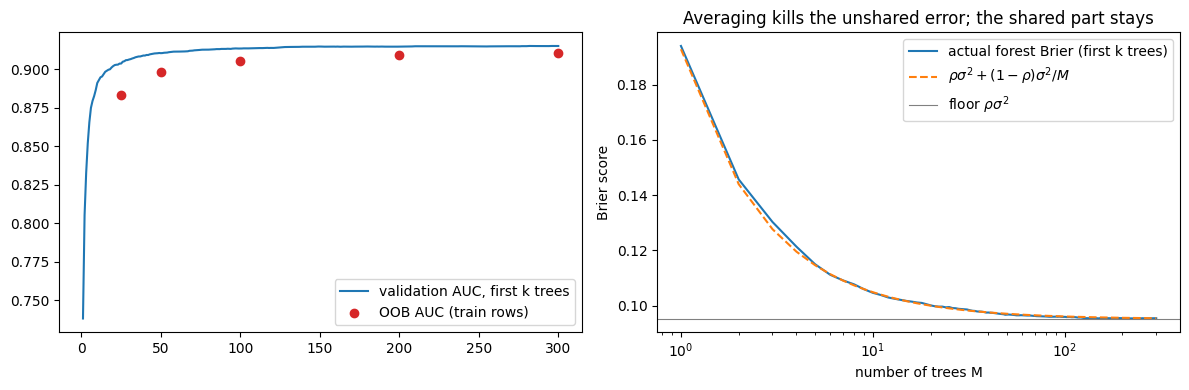

In [18]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(ks, auc_curve, label="validation AUC, first k trees")
axes[0].scatter(oob_df.M, oob_df.oob_auc, color="C3", zorder=3, label="OOB AUC (train rows)")
axes[0].legend()
axes[1].plot(ks, brier_curve, label="actual forest Brier (first k trees)")
axes[1].plot(ks, formula_curve, "--", label=r"$\rho\sigma^2 + (1-\rho)\sigma^2/M$")
axes[1].axhline(rho * sigma2, color="gray", lw=0.8, label=r"floor $\rho\sigma^2$")
axes[1].set(xscale="log", xlabel="number of trees M", ylabel="Brier score",
          title="Averaging kills the unshared error; the shared part stays")
axes[1].legend()
fig.tight_layout()
fig.savefig("rf_3_growing_forest.png", dpi=120)
plt.show()

both flatten around $M \approx 100$, which is  answer for n_estimators.
for next cell
That pipeline's model has warm_start=True and n_estimators=300 already fitted. If you set_params(model__max_features=...) and call fit again with the same n_estimators, sklearn doesn't retrain — it warns that warm-start fitting without increasing n_estimators adds no trees, and keeps the existing 300 trees unchanged

max feature sweep

In [19]:
from sklearn.base import clone

n_feat=len(features)
mf_grid=[1,'sqrt',0.5,1.0]
M_SWEEP=200
mf_rows=[]
base = Pipeline([
    ("prep", preproces),
    ("model", RandomForestClassifier(n_estimators=M_SWEEP, n_jobs=N_jobs,
                                     random_state=SEED)),   # no warm_start, no oob_score
])
for mf in mf_grid:
    p=clone(base).set_params(model__max_features=mf)
    p.fit(X_tr,y_tr)

    rf_mf=p.named_steps['model']
    P=per_tree_proba(rf_mf,p[:-1].transform(X_val).to_numpy())
    s2,r,fb=error_decomposition(P,y_val)
    mf_rows.append({
    "max_features": mf,
    "feats_per_split": rf_mf.estimators_[0].max_features_,
    "sigma2": s2,
    "rho": r,
    "floor": r * s2,
    "averaged_away": (1 - r) * s2 / M_SWEEP,
    "forest_brier": fb,
    "single_tree_auc": np.mean([roc_auc_score(y_val, p_t) for p_t in P]),
    "forest_auc": roc_auc_score(y_val, P.mean(0)),
})

mf_df=pd.DataFrame(mf_rows)
print(mf_df.round(4).to_string(index=False))
best_mf = mf_df.loc[mf_df.forest_auc.idxmax(), "max_features"]
print(f"best max_features on validation AUC: {best_mf}")



max_features  feats_per_split  sigma2    rho  floor  averaged_away  forest_brier  single_tree_auc  forest_auc
           1                1  0.2046 0.4755 0.0973         0.0005        0.0978           0.7196      0.9132
        sqrt                3  0.1926 0.4932 0.0950         0.0005        0.0955           0.7380      0.9148
         0.5                7  0.1901 0.5048 0.0960         0.0005        0.0964           0.7422      0.9118
         1.0               15  0.1908 0.5128 0.0979         0.0005        0.0983           0.7425      0.9076
best max_features on validation AUC: sqrt


max_features sweep - readout

The trade. sigma2 falls 0.2046 -> 0.1926 -> 0.1901 -> 0.1908: more features per split means a stronger individual tree. rho rises 0.4755 -> 0.4932 -> 0.5048 -> 0.5128: more features means trees pick the same dominant splits, so errors coincide. Neither column alone has a useful optimum; the product rho*sigma2 does.

Floor is U-shaped, minimised at sqrt: 0.0973 -> 0.0950 -> 0.0960 -> 0.0979. sqrt trades a little sigma2 for a worthwhile drop in rho. max_features=1 has the lowest correlation but trees too weak to exploit it. max_features=1.0 has the strongest trees but they are nearly redundant. forest_auc agrees, 0.9148 at sqrt is the max - two criteria, same winner.

averaged_away is 0.0005 in every row, about 0.5% of the floor. Averaging is fully exhausted at M=200; more trees change nothing in any config. So the forest_brier ranking is just the floor ranking plus a constant.

Individual tree quality is not ensemble quality. single_tree_auc rises monotonically 0.7196 -> 0.7425 while forest_auc peaks at sqrt then falls to 0.9076. The best trees (1.0) build the worst forest. Tuning on tree strength alone would pick exactly wrong.

Actions. Keep max_features="sqrt" (the default); spread across the grid is only 0.007 AUC, so stop sweeping it. Drop to ~100 trees; 300 buys nothing. Floor ~0.095 is where this model class lands - to go lower, attack rho: ExtraTreesClassifier randomises split thresholds too, usually cutting rho without the sigma2 penalty that max_features=1 imposes.

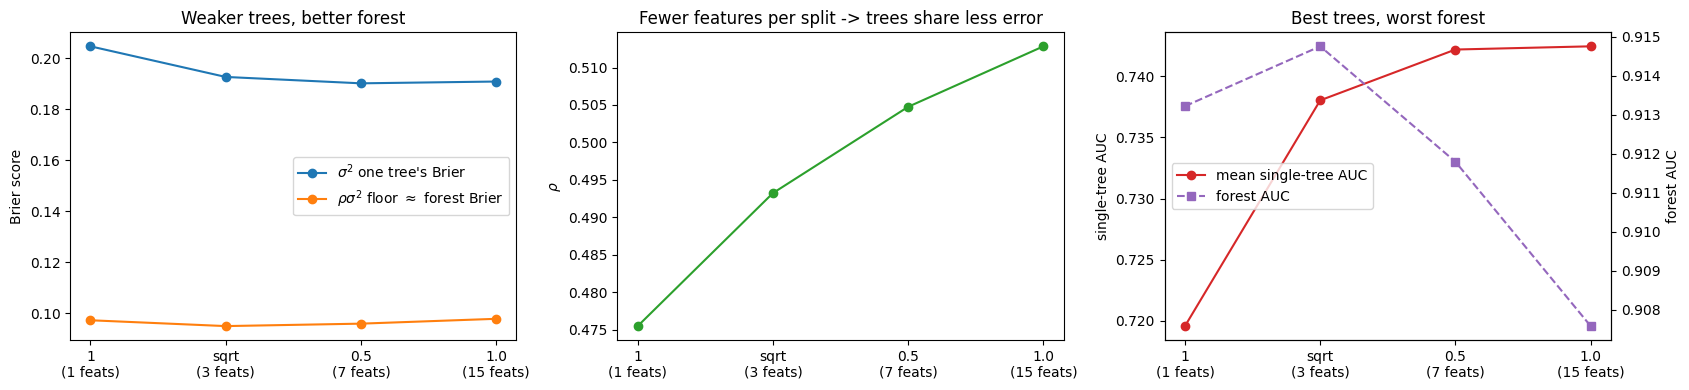

In [20]:
labels = [f"{m}\n({k} feats)" for m, k in zip(mf_df.max_features, mf_df.feats_per_split)]
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(labels, mf_df.sigma2, "o-", label=r"$\sigma^2$ one tree's Brier")
ax[0].plot(labels, mf_df.floor, "o-", label=r"$\rho\sigma^2$ floor $\approx$ forest Brier")
ax[0].set(ylabel="Brier score", title="Weaker trees, better forest")
ax[0].legend()

ax[1].plot(labels, mf_df.rho, "o-", color="C2")
ax[1].set(ylabel=r"$\rho$", title="Fewer features per split -> trees share less error")

ax[2].plot(labels, mf_df.single_tree_auc, "o-", color="C3", label="mean single-tree AUC")
ax[2].set(ylabel="single-tree AUC", title="Best trees, worst forest")
ax2 = ax[2].twinx()
ax2.plot(labels, mf_df.forest_auc, "s--", color="C4", label="forest AUC")
ax2.set_ylabel("forest AUC")
h1, l1 = ax[2].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax[2].legend(h1 + h2, l1 + l2, loc="center left")

fig.tight_layout()
fig.savefig("rf_4_max_features.png", dpi=120)
plt.show()

In [21]:
msl_grid = [1, 5, 20, 50, 100]
msl_rows = []

for msl in msl_grid:
    p = clone(base).set_params(model__max_features=best_mf,
                               model__min_samples_leaf=msl)
    p.fit(X_tr, y_tr)
    rf_t = p.named_steps['model']

    P = per_tree_proba(rf_t, p[:-1].transform(X_val).to_numpy())
    s2, r, fb = error_decomposition(P, y_val)

    msl_rows.append({
        "min_samples_leaf": msl,
        "sigma2": s2,
        "rho": r,
        "floor": r * s2,
        "forest_brier": fb,
        "single_tree_auc": np.mean([roc_auc_score(y_val, p_t) for p_t in P]),
        "val_auc": roc_auc_score(y_val, P.mean(0)),
        "avg_leaves_per_tree": np.mean([t.get_n_leaves() for t in rf_t.estimators_]),
    })

msl_df = pd.DataFrame(msl_rows)
print(msl_df.round(4).to_string(index=False))
best_msl=msl_df.loc[msl_df['val_auc'].idxmax(),'min_samples_leaf']
print(f"best min_samples_leaf by val AUC: {best_msl}" )

 min_samples_leaf  sigma2    rho  floor  forest_brier  single_tree_auc  val_auc  avg_leaves_per_tree
                1  0.1926 0.4932 0.0950        0.0955           0.7380   0.9148             3947.745
                5  0.1244 0.7535 0.0937        0.0939           0.8531   0.9190             1162.680
               20  0.1112 0.8629 0.0959        0.0960           0.8817   0.9172              395.660
               50  0.1112 0.8873 0.0987        0.0988           0.8829   0.9145              189.760
              100  0.1138 0.8922 0.1015        0.1016           0.8776   0.9114              105.340
best min_samples_leaf by val AUC: 5


In [22]:
final = clone(base).set_params(model__max_features=best_mf,
                               model__min_samples_leaf=best_msl,
                               model__oob_score=True)
final.fit(X_tr, y_tr)



,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('encode', ...), ('cast', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [23]:


from sklearn.inspection import permutation_importance
prem_val=permutation_importance(final,X_val,y_val,scoring='roc_auc',n_repeats=10,random_state=SEED,n_jobs=N_jobs)

sub = rng.choice(len(X_tr), size=min(10_000, len(X_tr)), replace=False)

perm_tr=permutation_importance(final,X_tr.iloc[sub],y_tr[sub],scoring='roc_auc',n_repeats=10,random_state=SEED,n_jobs=N_jobs)
mdi = pd.Series(final.named_steps['model'].feature_importances_,
                index=final.named_steps['prep'].get_feature_names_out()
               ).sort_values(ascending=False)
cols=X_val.columns #perm arrays are in input order 

imp = pd.DataFrame({
    "MDI": mdi,
    "perm_val": pd.Series(prem_val.importances_mean, index=cols),
    "perm_val_std": pd.Series(prem_val.importances_std, index=cols),
    "perm_train": pd.Series(perm_tr.importances_mean, index=cols),
    "n_unique": X[features].nunique(),
})
imp["MDI_rank"] = imp.MDI.rank(ascending=False).astype(int)
imp["perm_val_rank"] = imp.perm_val.rank(ascending=False).astype(int)
imp = imp.sort_values("perm_val",ascending=False)
print(imp.round(4).to_string())


                   MDI  perm_val  perm_val_std  perm_train  n_unique  MDI_rank  perm_val_rank
capital-gain    0.1597    0.0478        0.0010      0.0431       123         2              1
relationship    0.1646    0.0371        0.0020      0.0464         6         1              2
education-num   0.1238    0.0282        0.0009      0.0453        16         3              3
age             0.0973    0.0242        0.0014      0.0420        74         5              4
marital-status  0.1031    0.0196        0.0017      0.0198         7         4              5
hours-per-week  0.0584    0.0137        0.0010      0.0288        96         6              6
capital-loss    0.0447    0.0082        0.0006      0.0089        99        10              7
occupation      0.0514    0.0073        0.0009      0.0251        14         9              8
education       0.0382    0.0030        0.0005      0.0126        16        11              9
workclass       0.0200    0.0028        0.0002      0.0091  

              precision    recall  f1-score   support

       <=50K     0.8848    0.9463    0.9145      7432
        >50K     0.7808    0.6080    0.6837      2337

    accuracy                         0.8654      9769
   macro avg     0.8328    0.7772    0.7991      9769
weighted avg     0.8599    0.8654    0.8593      9769



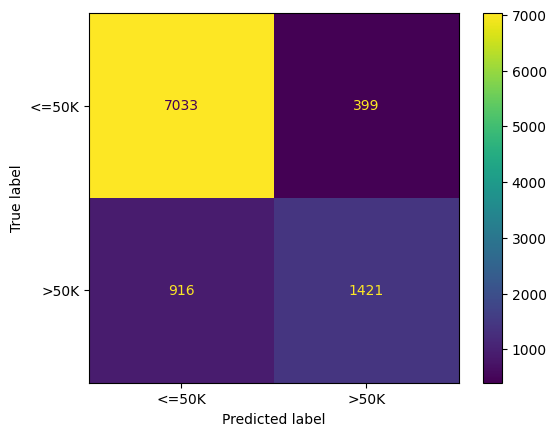

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_val_pred = final.predict(X_val)

print(classification_report(y_val, y_val_pred, target_names=["<=50K", ">50K"], digits=4))
# print(confusion_matrix(y_val, y_val_pred))
ConfusionMatrixDisplay.from_estimator(final, X_val, y_val, display_labels=["<=50K", ">50K"])

In [25]:
drop = ["fnlwgt", "random_noise"]
num_cols_v2 = [c for c in num_cols if c not in drop]
cat_cols_v2 = [c for c in cat_cols if c not in drop]

preproc_v2 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols_v2),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                               encoded_missing_value=np.nan), cat_cols_v2),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

final_v2 = Pipeline([
    ("prep", preproc_v2),
    ("model", RandomForestClassifier(n_estimators=200, max_features=best_mf,
                                     min_samples_leaf=best_msl,
                                     n_jobs=N_jobs, random_state=SEED)),
])
final_v2.fit(X_tr, y_tr)

print(f"val AUC before drop: {roc_auc_score(y_val, final.predict_proba(X_val)[:,1]):.4f}")
print(f"val AUC after  drop: {roc_auc_score(y_val, final_v2.predict_proba(X_val)[:,1]):.4f}")

val AUC before drop: 0.9190
val AUC after  drop: 0.9202


In [26]:
from sklearn.model_selection import TunedThresholdClassifierCV, StratifiedKFold
from sklearn.metrics import make_scorer, confusion_matrix

def net_cost(y_true, y_pred, c_fp=1, c_fn=3):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(c_fp * fp + c_fn * fn)

cv = StratifiedKFold(3, shuffle=True, random_state=SEED)
sweep_rows = []

for c_fn in [1, 2, 3, 5, 10]:
    t = TunedThresholdClassifierCV(
        final_v2,
        scoring=make_scorer(net_cost, c_fn=c_fn),
        cv=cv, refit=True, n_jobs=N_jobs,
    ).fit(X_tr, y_tr)

    tn, fp, fn, tp = confusion_matrix(y_val, t.predict(X_val)).ravel()
    sweep_rows.append({
        "c_fn": c_fn,
        "tau": t.best_threshold_,
        "tau_ideal": 1 / (1 + c_fn),
        "FP": fp,
        "FN": fn,
        "precision": tp / (tp + fp),
        "recall": tp / (tp + fn),
        "accuracy": (tp + tn) / len(y_val),
        "val_cost": fp + c_fn * fn,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.round(4).to_string(index=False))

 c_fn    tau  tau_ideal   FP  FN  precision  recall  accuracy  val_cost
    1 0.4941     0.5000  421 872     0.7768  0.6269    0.8676      1293
    2 0.3428     0.3333  981 520     0.6494  0.7775    0.8464      2021
    3 0.2924     0.2500 1250 402     0.6075  0.8280    0.8309      2456
    5 0.1916     0.1667 1886 198     0.5314  0.9153    0.7867      2876
   10 0.1109     0.0909 2570  99     0.4655  0.9576    0.7268      3560


### Threshold sweep — why we ship `final_v2` at tau = 0.5

`TunedThresholdClassifierCV` does not change the model: it cross-validates on train,
collects out-of-fold probabilities, and picks the cut maximising a scorer. AUC is
untouched by construction; only the operating point moves.

The scorer encodes an assumption, so we swept it rather than inventing one ratio:
`net_cost = -(c_fp*FP + c_fn*FN)`, negated because sklearn maximises.

**Accuracy falls monotonically down the sweep, and that is correct.** `c_fn=1` *is*
the accuracy objective — equal weights means minimising cost = minimising error count.
Every row below trades accuracy for recall deliberately. Judging one row by another
row's metric is the mistake to avoid; `val_cost` is in different units per row and is
likewise not a ranking.

**tau vs tau_ideal is the calibration readout.** For calibrated probabilities the
cost-optimal cut is computable: `tau* = 1/(1+c_fn)`. The gap is ~0 at c_fn=1, where
most probability mass sits, and opens to +0.04 in the tail. That gap is the Brier
floor (~0.094) surfacing as a decision cost — the reason tau needs empirical tuning
rather than derivation.

**Decision: ship `final_v2` at the default 0.5.** No business cost structure is stated
here, so c_fn=1 is the only defensible assumption — and the tuner independently
confirms it, landing on 0.4941. Tuning for F1 or an invented c_fn=3 would optimise a
problem we do not have.


Headline: val AUC 0.920, accuracy 0.867, >50K recall 0.620 at precision 0.779.


In [27]:
X_val_v2 = X_val.drop(columns=drop)

names = final_v2.named_steps["prep"].get_feature_names_out()
mdi = pd.Series(final_v2.named_steps["model"].feature_importances_, index=names)

r = permutation_importance(final_v2, X_val_v2, y_val, scoring="roc_auc",
                           n_repeats=10, random_state=SEED, n_jobs=N_jobs)
perm = pd.Series(r.importances_mean, index=X_val_v2.columns)
perm_std = pd.Series(r.importances_std, index=X_val_v2.columns)

imp_final = pd.DataFrame({
    "MDI": mdi,
    "perm_val": perm,
    "perm_val_std": perm_std,
    "n_unique": X[X_val_v2.columns].nunique(),
}).sort_values("perm_val", ascending=False)

imp_final["MDI_rank"] = imp_final.MDI.rank(ascending=False).astype(int)
imp_final["perm_rank"] = imp_final.perm_val.rank(ascending=False).astype(int)
print(imp_final.round(4).to_string())

                   MDI  perm_val  perm_val_std  n_unique  MDI_rank  perm_rank
capital-gain    0.1801    0.0492        0.0011       123         1          1
relationship    0.1726    0.0334        0.0018         6         2          2
education-num   0.1448    0.0301        0.0012        16         3          3
age             0.1116    0.0244        0.0013        74         5          4
marital-status  0.1259    0.0226        0.0017         7         4          5
hours-per-week  0.0628    0.0143        0.0011        96         6          6
capital-loss    0.0496    0.0088        0.0007        99         8          7
occupation      0.0532    0.0078        0.0010        14         7          8
workclass       0.0239    0.0032        0.0002         8        10          9
education       0.0407    0.0024        0.0005        16         9         10
sex             0.0189    0.0011        0.0005         2        11         11
native-country  0.0094    0.0006        0.0002        41        

In [28]:
from sklearn.ensemble import ExtraTreesClassifier
et = Pipeline([
    ("prep", preproc_v2),
    ("model", ExtraTreesClassifier(n_estimators=200, max_features=best_mf,
                                   min_samples_leaf=best_msl,
                                   n_jobs=N_jobs, random_state=SEED)),
]).fit(X_tr, y_tr)

P_et = per_tree_proba(et.named_steps["model"], et[:-1].transform(X_val).to_numpy())
s2, r, fb = error_decomposition(P_et, y_val)
print(f"sigma2={s2:.4f}  rho={r:.4f}  floor={r*s2:.4f}  val_auc={roc_auc_score(y_val, P_et.mean(0)):.4f}")

sigma2=0.1151  rho=0.8784  floor=0.1011  val_auc=0.9116


In [29]:
from sklearn.ensemble import ExtraTreesClassifier
et = Pipeline([
    ("prep", preproc_v2),
    ("model", ExtraTreesClassifier(n_estimators=200, max_features=best_mf,
                                   min_samples_leaf=best_msl,
                                   n_jobs=N_jobs, random_state=SEED,bootstrap=True,max_samples=1.0)),
]).fit(X_tr, y_tr)

P_et = per_tree_proba(et.named_steps["model"], et[:-1].transform(X_val).to_numpy())
s2, r, fb = error_decomposition(P_et, y_val)
print(f"sigma2={s2:.4f}  rho={r:.4f}  floor={r*s2:.4f}  val_auc={roc_auc_score(y_val, P_et.mean(0)):.4f}")

sigma2=0.1182  rho=0.8650  floor=0.1023  val_auc=0.9099


Text(0.5, 1.0, 'Reliability ')

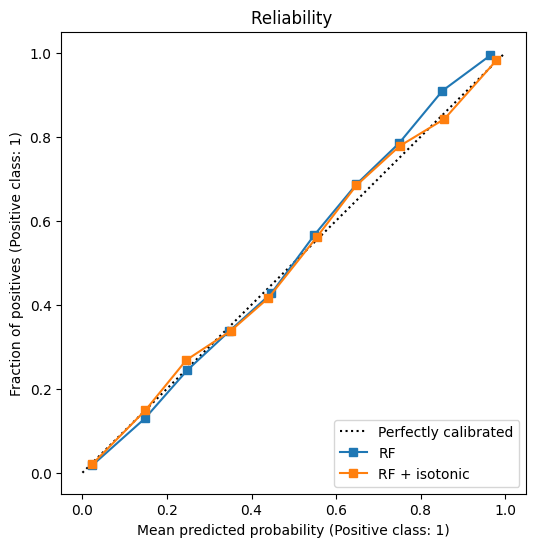

In [36]:
from sklearn.calibration import CalibrationDisplay,CalibratedClassifierCV

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_estimator(final_v2, X_val, y_val, n_bins=10, ax=ax, name="RF")

cal = CalibratedClassifierCV(final_v2, method="isotonic", cv=5).fit(X_tr, y_tr)
CalibrationDisplay.from_estimator(cal, X_val, y_val, n_bins=10, ax=ax, name="RF + isotonic")
ax.set_title("Reliability ")


In [31]:
from sklearn.ensemble import ExtraTreesClassifier

candidates = {
    "RF (sqrt, msl=5)": RandomForestClassifier(
        n_estimators=200, max_features=best_mf, min_samples_leaf=best_msl,
        n_jobs=N_jobs, random_state=SEED),
    "ET (bootstrap=False)": ExtraTreesClassifier(
        n_estimators=200, max_features=best_mf, min_samples_leaf=best_msl,
        bootstrap=False, n_jobs=N_jobs, random_state=SEED),
    "ET (bootstrap=True)": ExtraTreesClassifier(
        n_estimators=200, max_features=best_mf, min_samples_leaf=best_msl,
        bootstrap=True, n_jobs=N_jobs, random_state=SEED),
}

cmp_rows = []
for name, est in candidates.items():
    pl = Pipeline([("prep", preproc_v2), ("model", est)]).fit(X_tr, y_tr)
    P = per_tree_proba(pl.named_steps["model"], pl[:-1].transform(X_val).to_numpy())
    s2, r, fb = error_decomposition(P, y_val)
    cmp_rows.append({
        "model": name,
        "sigma2": s2,
        "rho": r,
        "floor": r * s2,
        "forest_brier": fb,
        "single_tree_auc": np.mean([roc_auc_score(y_val, p_t) for p_t in P]),
        "val_auc": roc_auc_score(y_val, P.mean(0)),
    })

cmp_df = pd.DataFrame(cmp_rows)
print(cmp_df.round(4).to_string(index=False))

               model  sigma2    rho  floor  forest_brier  single_tree_auc  val_auc
    RF (sqrt, msl=5)  0.1124 0.8254 0.0928        0.0929           0.8759   0.9202
ET (bootstrap=False)  0.1151 0.8784 0.1011        0.1012           0.8735   0.9116
 ET (bootstrap=True)  0.1182 0.8650 0.1023        0.1023           0.8664   0.9099


### RF vs ExtraTrees — threshold randomisation does not help here

**The hypothesis.** The tuned RF sits at rho = 0.8254: four fifths of a tree's error is
shared with every other tree, and that floor (rho*sigma2 = 0.0928) is the binding
constraint. Every knob swept so far (max_features, min_samples_leaf) pushed rho the
*wrong* way. ExtraTrees attacks it from a direction the others cannot — instead of
searching for the best threshold on each candidate column, it draws thresholds at
random, so two trees handed the same column no longer land on the same cut.

**The result: rho went UP, not down.** 0.8254 -> 0.8784 (bootstrap=False) -> 0.8650
(bootstrap=True). Restoring row sampling recovered almost nothing, so `bootstrap=False`
was not the explanation.

**What actually happened: ET lost on BOTH terms.** sigma2 rose too (0.1124 -> 0.1151 /
0.1182), and mean single-tree AUC fell (0.8759 -> 0.8735 / 0.8664) — individual ET trees
are *worse* than RF trees here, not better. So the floor rose on both counts
(0.0928 -> 0.1011 / 0.1023). The randomisation did not trade tree quality for diversity;
it gave up tree quality and got less diversity as well.

This fits the data, and one cause explains both columns. Adult has features with
genuinely sharp thresholds — capital-gain is near-deterministic at zero vs nonzero,
education-num and age have real cutoffs. The RF's exhaustive threshold search finds them.
Random cuts miss them, which makes each tree worse (sigma2 up), and every tree misses
them *in the same way*, which is shared bias rather than variance (rho up).

Threshold randomisation buys diversity only when the exact split location does not matter
much. Here it does.

**Decision: keep `final_v2` (RF).** val AUC 0.9202 vs 0.9116 / 0.9099.

rho ~= 0.83 looks intrinsic to this problem, not an artifact of tuning — which means the
Brier floor of ~0.093 is roughly where this model class lands on adult. Further ensemble
tuning is not the lever. If better probabilities are needed, calibration is (isotonic on
top of the RF: AUC unchanged by monotonicity, Brier improves).


In [32]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)

artifact = {
    "pipeline": final_v2,
    "features": list(X_val_v2.columns),
    "threshold": 0.5,
    "val_auc": roc_auc_score(y_val, final_v2.predict_proba(X_val_v2)[:, 1]),
    "params": {"max_features": best_mf, "min_samples_leaf": best_msl, "n_estimators": 200},
    "sklearn_version": sklearn.__version__,
    "trained": pd.Timestamp.now().isoformat(),
}

joblib.dump(artifact, "models/rf_adult_v2.joblib", compress=3)

['models/rf_adult_v2.joblib']

In [33]:
a = joblib.load("models/rf_adult_v2.joblib")
proba = a["pipeline"].predict_proba(df[a["features"]])[:, 1]
pred = (proba >= a["threshold"]).astype(int)
pred

array([0, 0, 1, ..., 0, 0, 1], shape=(48842,))

In [34]:
roc_auc_score(y_test, a["pipeline"].predict_proba(X_test[a["features"]])[:, 1])

0.9181515278457446

In [37]:
proba_test = a["pipeline"].predict_proba(X_test[a["features"]])[:, 1]
pred_test = (proba_test >= a["threshold"]).astype(int)

print(classification_report(y_test, pred_test, target_names=["<=50K", ">50K"], digits=4))
print(confusion_matrix(y_test, pred_test))
print(f"\ntest Brier: {brier_score_loss(y_test, proba_test):.4f}")

              precision    recall  f1-score   support

       <=50K     0.8865    0.9466    0.9155      7431
        >50K     0.7835    0.6146    0.6889      2338

    accuracy                         0.8671      9769
   macro avg     0.8350    0.7806    0.8022      9769
weighted avg     0.8618    0.8671    0.8613      9769

[[7034  397]
 [ 901 1437]]

test Brier: 0.0932


Random forest on UCI Adult: test AUC 0.918, Brier 0.093, accuracy 0.867.

Error decomposition shows $\rho \approx 0.83$ — four fifths of a single tree's error is shared across the ensemble. The variance term $(1-\rho)\sigma^2/M$ was exhausted by ~100 trees, so the remaining error is shared bias, which bagging cannot reduce. The predicted floor $\rho\sigma^2 = 0.0928$ matched the test Brier of 0.0932.


This is why boosting is the next step rather than more forest tuning: sequential residual fitting attacks shared bias directly, which independent averaging structurally cannot.